In [5]:
import torch
import matplotlib.pyplot as plt

print(torch.__version__)


2.10.0+cpu


In [6]:
def forrester_1d(x):
    y = -((x + 1) ** 2) * torch.sin(2 * x + 2) / 5 + 1
    return y.squeeze(-1)

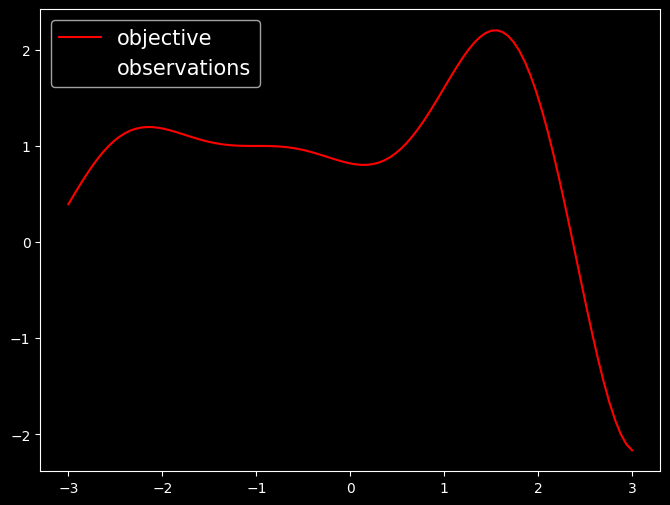

In [7]:
xs = torch.linspace(-3, 3, 101).unsqueeze(1)
ys = forrester_1d(xs)
torch.manual_seed(0)
train_x = torch.rand(size=(3, 1)) * 6 - 3
train_y = forrester_1d(train_x)
plt.figure(figsize=(8, 6))
plt.plot(xs, ys, label="objective", c="r")
plt.scatter(train_x, train_y, marker="x", c="k", label="observations")
plt.legend(fontsize=15)

In [8]:
import gpytorch

print(gpytorch.__version__)


1.15.1


In [9]:
class BaseGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ZeroMean()
        self.covar_module = gpytorch.kernels.RBFKernel()
    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [11]:
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = BaseGPModel(None, None, likelihood)

In [12]:
lengthscale = 1
noise = 1e-4
model.covar_module.lengthscale = lengthscale
model.likelihood.noise = noise
model.eval()
likelihood.eval()

GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-04)
  )
)